# Home assignment #4

## Сравним как меняется количество «гауссиан» (Splatts) в процессе обучения

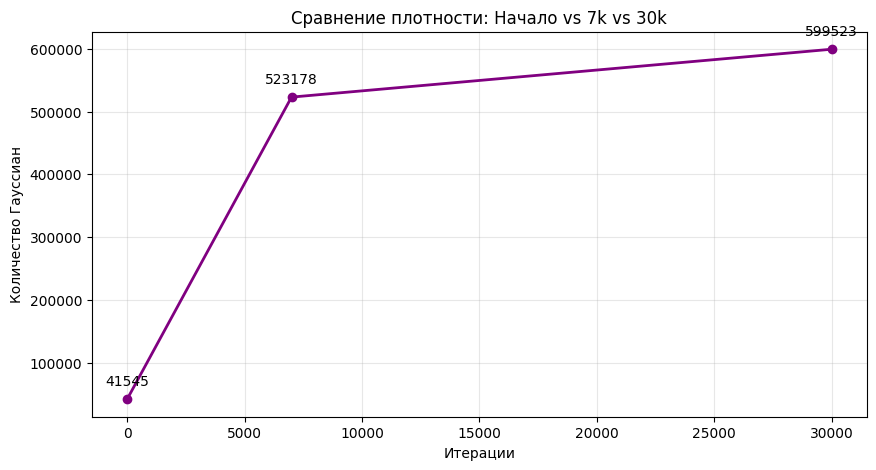

In [12]:
import os
import matplotlib.pyplot as plt
from plyfile import PlyData

def get_count(iteration):
    path = rf"B:\Python projects\inno\Robotics\Robotics_Course\HW4\gaussian-splatting\output\1737e347-c\point_cloud\iteration_{iteration}\point_cloud.ply"
    return PlyData.read(path).elements[0].count if os.path.exists(path) else None

iters = [0, 7000, 30000]
counts = [41545, get_count(7000), get_count(30000)]

plot_iters = [i for i, c in zip(iters, counts) if c is not None]
plot_counts = [c for c in counts if c is not None]
plt.figure(figsize=(10, 5))
plt.plot(plot_iters, plot_counts, marker='o', color='purple', linewidth=2, label='Splat Count')
for i, txt in enumerate(plot_counts):
    plt.annotate(txt, (plot_iters[i], plot_counts[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Сравнение плотности: Начало vs 7k vs 30k")
plt.xlabel("Итерации")
plt.ylabel("Количество Гауссиан")
plt.grid(True, alpha=0.3)
plt.show()

## Используем встроенные средства для обрезки фонового шума вокруг объекта

In [22]:
import numpy as np
from plyfile import PlyData, PlyElement

def crop_point_cloud(input_path, output_path, min_x, max_x, min_y, max_y, min_z, max_z):
    plydata = PlyData.read(input_path)
    vertex = plydata['vertex']
    
    mask = (vertex['x'] > min_x) & (vertex['x'] < max_x) & \
           (vertex['y'] > min_y) & (vertex['y'] < max_y) & \
           (vertex['z'] > min_z) & (vertex['z'] < max_z)
    
    filtered_vertex = vertex[mask]
    
    el = PlyElement.describe(filtered_vertex, 'vertex')
    PlyData([el], text=False).write(output_path)
    
    print(f"Оригинальное количество точек: {len(vertex)}")
    print(f"После обрезки осталось: {len(filtered_vertex)}")

input_ply = r"B:\Python projects\inno\Robotics\Robotics_Course\HW4\gaussian-splatting\output\1737e347-c\point_cloud\iteration_7000\point_cloud.ply"
output_ply = r"B:\Python projects\inno\Robotics\Robotics_Course\HW4\gaussian-splatting\output\1737e347-c\teapot_cropped.ply"

crop_point_cloud(input_ply, output_ply, 
                 min_x=-5.0, max_x=5.0, 
                 min_y=-5.0, max_y=5.0, 
                 min_z=-5.0, max_z=5.0)

Оригинальное количество точек: 523178
После обрезки осталось: 257800


## Сравнение разреженного облака точек (COLMAP) и финального рендера (GS) для 7К и 30К точек

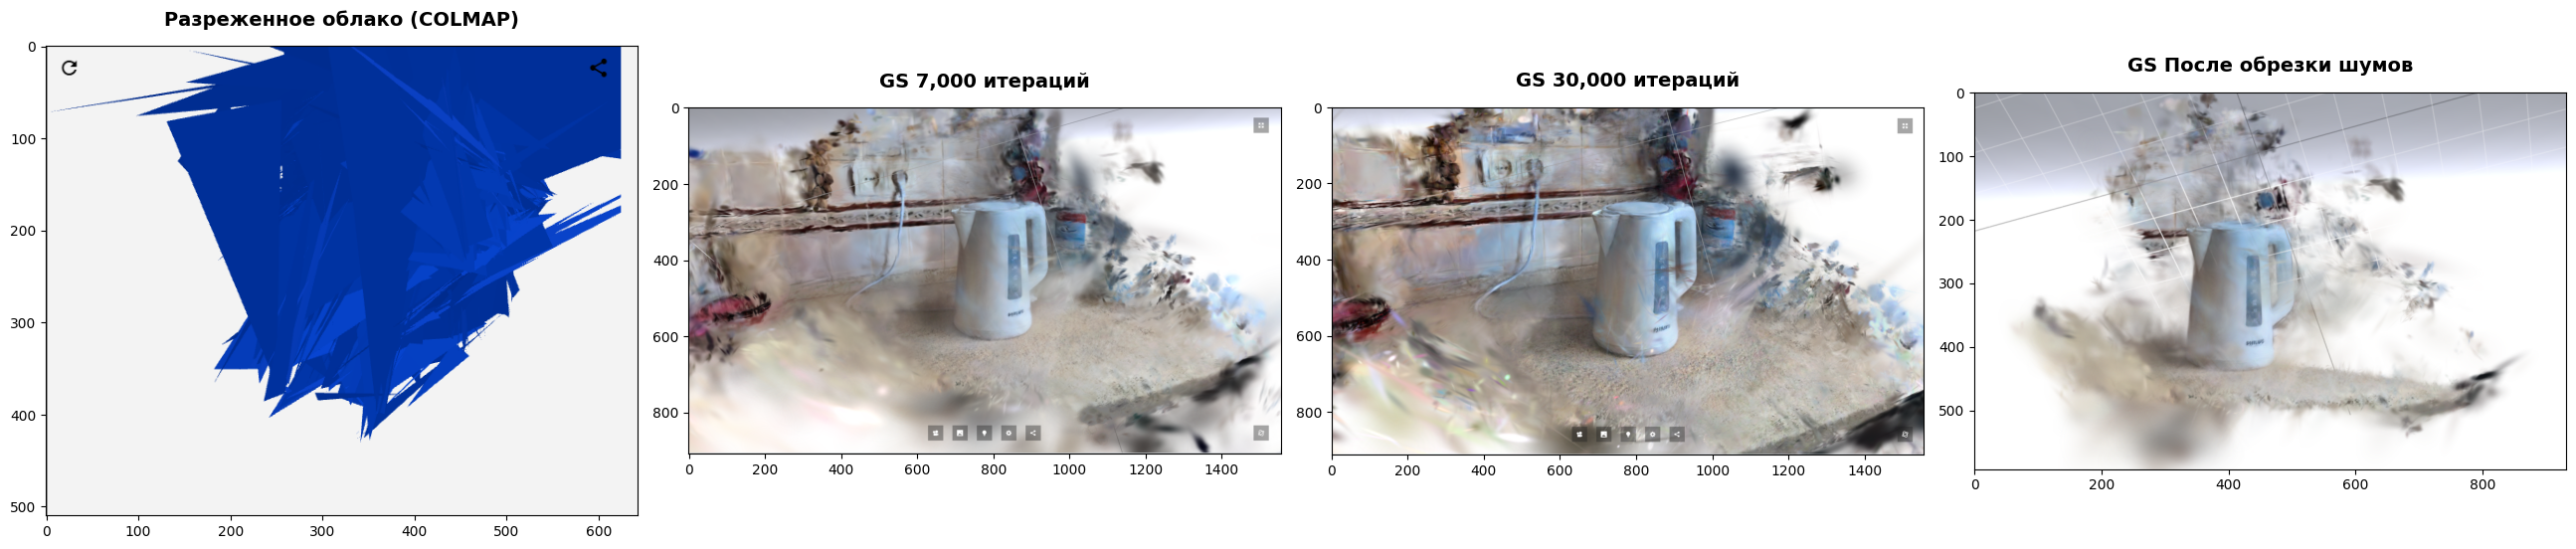

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os

path_colmap = r"B:\Python projects\inno\Robotics\Robotics_Course\HW4\colmap.png"
path_7k = r"B:\Python projects\inno\Robotics\Robotics_Course\HW4\7000K.png"
path_30k = r"B:\Python projects\inno\Robotics\Robotics_Course\HW4\30000K.png"
path_cropped = r"B:\Python projects\inno\Robotics\Robotics_Course\HW4\cropped_version.png"

images_to_show = [
    ("Разреженное облако (COLMAP)", path_colmap),
    ("GS 7,000 итераций", path_7k),
    ("GS 30,000 итераций", path_30k),
    ("GS После обрезки шумов", path_cropped)
]

fig, axes = plt.subplots(1, 4, figsize=(26, 7))

for ax, (title, img_path) in zip(axes, images_to_show):
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()